In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from sklearn.linear_model import LinearRegression

 
# Show all Matplotlib plots directly inside the notebook, right below the code cell that produced them
%matplotlib inline

### Data Profiling

In [6]:
df = pd.read_csv("National_River_Toxin_Dataset_1.csv")
df.head()

,Date,River_System,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,2018-01-01,Amazon,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,2018-01-01,Nile,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,2018-01-01,Yangtze,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,2018-01-01,Mississippi,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,2018-01-01,Danube,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925


In [7]:
df.shape

(1305, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1305 non-null   object 
 1   River_System      1305 non-null   object 
 2   pH_Level          1278 non-null   float64
 3   Temperature       1278 non-null   float64
 4   Lead              1285 non-null   float64
 5   Mercury           1278 non-null   float64
 6   Arsenic           1279 non-null   float64
 7   Nitrates          1265 non-null   float64
 8   Phosphates        1282 non-null   float64
 9   Dissolved_Oxygen  1284 non-null   float64
dtypes: float64(8), object(2)
memory usage: 102.1+ KB


In [9]:
df.describe()

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
count,1278.000000,1278.000000,1285.000000,1278.000000,1279.000000,1265.000000,1282.000000,1284.000000
mean,7.353247,20.041668,3.011035,0.596108,3.597916,10.038789,0.497162,8.023795
std,0.349114,4.063638,0.874431,0.175150,0.992052,2.096641,0.106304,1.064190
min,6.465087,9.891618,0.551349,0.157117,1.485608,2.025075,0.144044,5.041394
25%,7.101324,16.813976,2.366298,0.462683,2.836160,8.701188,0.422006,7.269386
50%,7.339326,20.039121,3.000714,0.599186,3.511678,10.089112,0.497631,8.007448
75%,7.585733,23.358634,3.676560,0.734863,4.298946,11.391686,0.572888,8.740828
max,8.392902,30.749449,5.800963,1.057494,6.232902,16.547073,0.870007,11.228677


### Cleaning

In [10]:
# checks for null values and sums them for each column
df.isna().sum()

Date                 0
River_System         0
pH_Level            27
Temperature         27
Lead                20
Mercury             27
Arsenic             26
Nitrates            40
Phosphates          23
Dissolved_Oxygen    21
dtype: int64

In [11]:
# Percentage of missing values per column
(df.isnull().mean() * 100).round(2)

Date                0.00
River_System        0.00
pH_Level            2.07
Temperature         2.07
Lead                1.53
Mercury             2.07
Arsenic             1.99
Nitrates            3.07
Phosphates          1.76
Dissolved_Oxygen    1.61
dtype: float64

In [12]:
# Filling missing values in numeric columns only
numeric_columns = df.select_dtypes(include=[np.number]).columns # select only numeric columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean()) # replacing nulls with mean

In [13]:
df[numeric_columns]

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925
...,...,...,...,...,...,...,...,...
1300,7.353247,21.760533,1.656464,0.466371,2.778257,8.932392,0.521475,8.789334
1301,7.214448,21.005255,1.395876,0.743100,4.243743,7.766917,0.624352,7.907600
1302,6.852077,18.841392,3.677048,0.634460,5.958020,9.855321,0.567842,10.983113
1303,7.923046,18.886274,3.229030,0.526015,3.904349,10.859932,0.498410,8.284721


In [14]:
# We have replaced all the nulls with the average for each numeric column
df.isna().sum()

Date                0
River_System        0
pH_Level            0
Temperature         0
Lead                0
Mercury             0
Arsenic             0
Nitrates            0
Phosphates          0
Dissolved_Oxygen    0
dtype: int64

In [15]:
# converting data column to datetime
df['Date'] = pd.to_datetime(df['Date'])

### Analysis & Visualisation

In [16]:
# Calculate average level of toxins
average_toxin_level = df[['Lead', 'Mercury', 'Arsenic']].mean()
print(f"Average Toxin Levels: \n{average_toxin_level}")

Average Toxin Levels: 
Lead       3.011035
Mercury    0.596108
Arsenic    3.597916
dtype: float64


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Top Polluted Rivers by Lead Levels: 
River_System
Yangtze        4.011200
Mississippi    3.478198
Nile           2.990203
Danube         2.544912
Amazon         2.030662
Name: Lead, dtype: float64


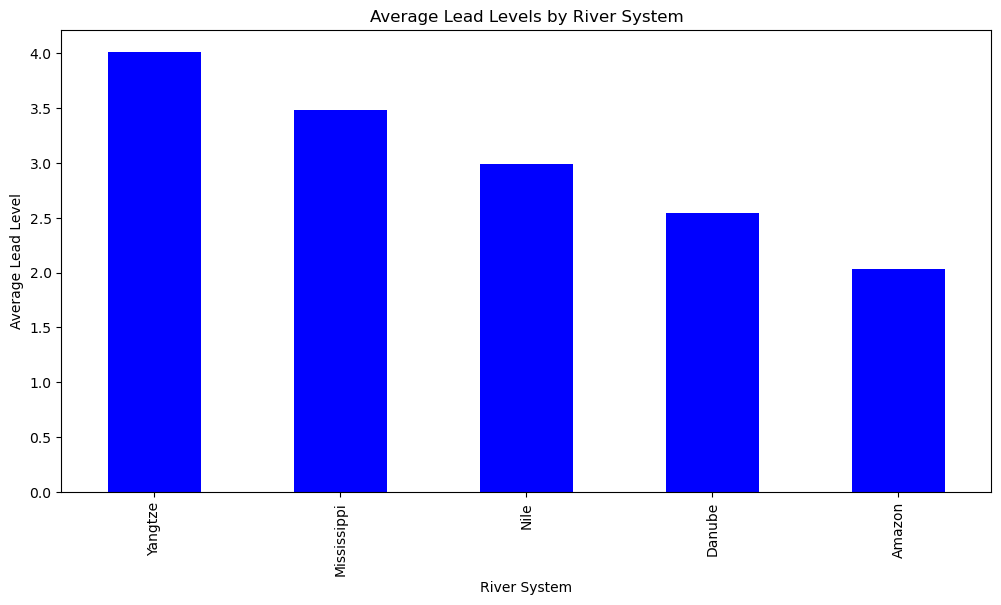

In [26]:
# Identify top Polluted rivers by average lead levels
top_polluted_rivers_lead = df.groupby('River_System')['Lead'].mean().sort_values(ascending=False)
print(f"Top Polluted Rivers by Lead Levels: \n{top_polluted_rivers_lead.head()}")

# plotting the lead levels pollution
plt.figure(figsize=(12, 6))
top_polluted_rivers_lead.plot(kind='bar', color='blue')
plt.title('Average Lead Levels by River System')
plt.xlabel('River System')
plt.ylabel('Average Lead Level')
plt.show()

In [18]:
# Identify top Polluted rivers by total lead levels
df.groupby('River_System')['Lead'].sum().sort_values(ascending=False)

River_System
Yangtze        1046.923320
Mississippi     907.809620
Nile            780.443013
Danube          664.222147
Amazon          530.002899
Name: Lead, dtype: float64

Nutrient levels by river:
              Nitrates  Phosphates  Total_Nutrients
River_System                                       
Nile            10.237       0.494           10.731
Mississippi     10.136       0.503           10.639
Danube           9.988       0.499           10.487
Yangtze          9.944       0.487           10.431
Amazon           9.888       0.504           10.392


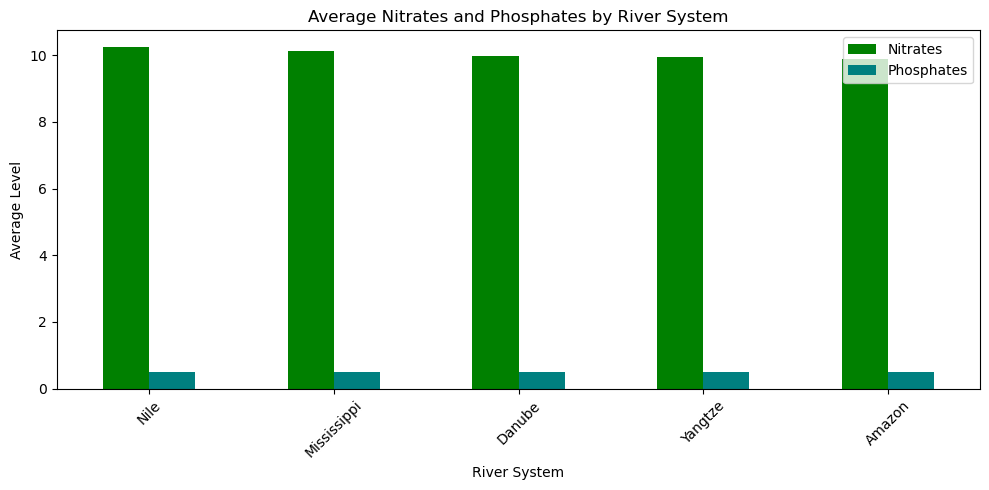

In [25]:
# Nutrient Analysis
nutrients = df.groupby('River_System')[['Nitrates', 'Phosphates']].mean().round(3)
nutrients['Total_Nutrients'] = nutrients['Nitrates'] + nutrients['Phosphates']
nutrients = nutrients.sort_values('Total_Nutrients', ascending=False)
print("Nutrient levels by river:")
print(nutrients)

nutrients[['Nitrates', 'Phosphates']].plot(kind='bar', figsize=(10, 5), color=['green', 'teal'])
plt.title('Average Nitrates and Phosphates by River System')
plt.xlabel('River System')
plt.ylabel('Average Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pH by river (below 7 = acidic, above 7 = basic):
               mean    min    max
River_System                     
Amazon        6.991  6.465  7.454
Yangtze       7.199  6.655  7.760
Danube        7.312  6.686  7.880
Nile          7.467  6.898  8.002
Mississippi   7.797  7.181  8.393

Most acidic river: Amazon (pH 6.991)
Most basic river:  Mississippi (pH 7.797)


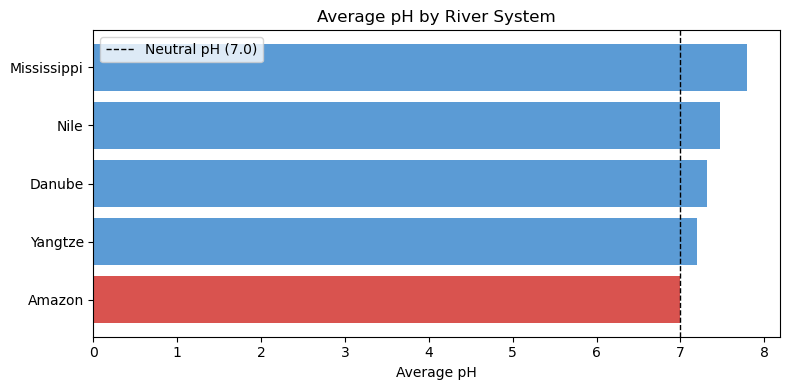

In [24]:
# pH Analysis — Acidity and Alkalinity
ph_by_river = df.groupby('River_System')['pH_Level'].agg(['mean', 'min', 'max']).round(3)
ph_by_river = ph_by_river.sort_values('mean')

print("pH by river (below 7 = acidic, above 7 = basic):")
print(ph_by_river)

# Most acidic (below 7)
acidic = ph_by_river[ph_by_river['mean'] < 7]
if not acidic.empty:
    print(f"\nMost acidic river: {acidic.index[0]} (pH {acidic['mean'].iloc[0]})")
else:
    print("\nNo rivers are acidic on average")

# Most basic (above 7)
basic = ph_by_river[ph_by_river['mean'] > 7]
print(f"Most basic river:  {basic.index[-1]} (pH {basic['mean'].iloc[-1]})")

# Plot
colors = ['#d9534f' if v < 7 else '#5b9bd5' for v in ph_by_river['mean']]

plt.figure(figsize=(8, 4))
bars = plt.barh(ph_by_river.index, ph_by_river['mean'], color=colors)
plt.axvline(x=7.0, color='black', linestyle='--', linewidth=1, label='Neutral pH (7.0)')
plt.title('Average pH by River System')
plt.xlabel('Average pH')
plt.legend()
plt.tight_layout()
plt.show()

### Outlier Detection

In [20]:
# Outlier Detection (IQR Method)
toxins = ['Lead', 'Mercury', 'Arsenic']

for toxin in toxins:
    Q1 = df[toxin].quantile(0.25)
    Q3 = df[toxin].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[toxin] < lower_bound) | (df[toxin] > upper_bound)]

    print(f"── {toxin} ──")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {len(outliers)}")
    if not outliers.empty:
        print(outliers[['Date', 'River_System', toxin]])
    print()

── Lead ──
  Bounds: [0.44, 5.60]
  Outliers found: 1
          Date River_System      Lead
837 2021-03-15      Yangtze  5.800963

── Mercury ──
  Bounds: [0.06, 1.13]
  Outliers found: 0

── Arsenic ──
  Bounds: [0.73, 6.41]
  Outliers found: 0



### Seasonal Trends

Yearly averages:
       Lead  Mercury  Arsenic
Year                         
2018  3.069    0.591    3.556
2019  3.034    0.588    3.623
2020  2.968    0.608    3.578
2021  3.020    0.598    3.639
2022  2.963    0.597    3.594


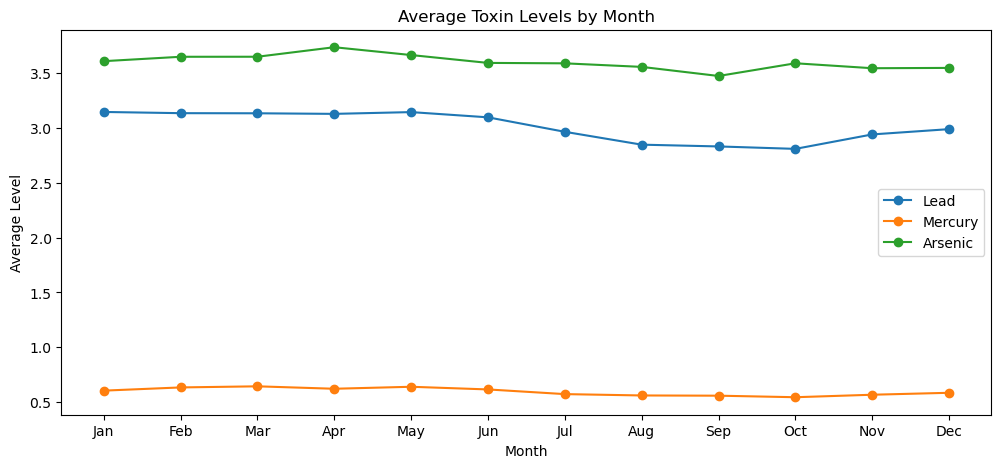

In [21]:
# Toxin Trends Over Time
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Yearly averages
print("Yearly averages:")
print(df.groupby('Year')[toxins].mean().round(3))

# Seasonal plot
monthly = df.groupby('Month')[toxins].mean()
monthly.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
for toxin in toxins:
    plt.plot(monthly.index, monthly[toxin], marker='o', label=toxin)

plt.title('Average Toxin Levels by Month')
plt.xlabel('Month')
plt.ylabel('Average Level')
plt.legend()
plt.show()

### Line graph for toxin levels over time

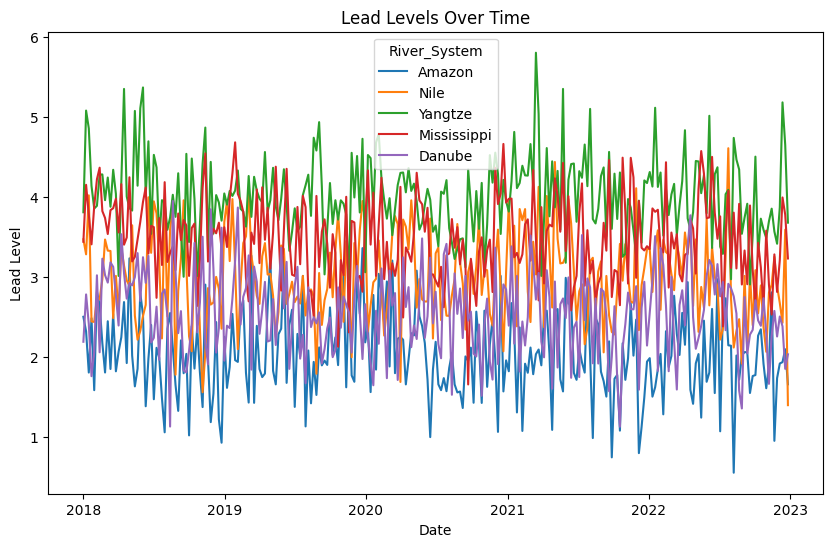

In [67]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Lead', data = df, hue = 'River_System', errorbar=None)
errorbar=None
plt.title('Lead Levels Over Time')
plt.xlabel('Date')
plt.ylabel('Lead Level')
plt.show()

### Correlation matrix using only numeric columns

In [69]:
corr_matrix = df[numeric_columns].corr() 
corr_matrix

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
pH_Level,1.000000,0.167589,0.319700,0.137656,0.042514,0.082121,0.089348,-0.058682
Temperature,0.167589,1.000000,0.124512,0.160928,0.044863,0.246166,0.314542,-0.279058
Lead,0.319700,0.124512,1.000000,0.538168,0.566595,0.029522,-0.000937,-0.027448
Mercury,0.137656,0.160928,0.538168,1.000000,0.685925,0.062318,0.005734,-0.001926
Arsenic,0.042514,0.044863,0.566595,0.685925,1.000000,0.034924,-0.004483,0.020435
Nitrates,0.082121,0.246166,0.029522,0.062318,0.034924,1.000000,0.099595,-0.092371
Phosphates,0.089348,0.314542,-0.000937,0.005734,-0.004483,0.099595,1.000000,-0.125113
Dissolved_Oxygen,-0.058682,-0.279058,-0.027448,-0.001926,0.020435,-0.092371,-0.125113,1.000000


#### Correlation Heatmap

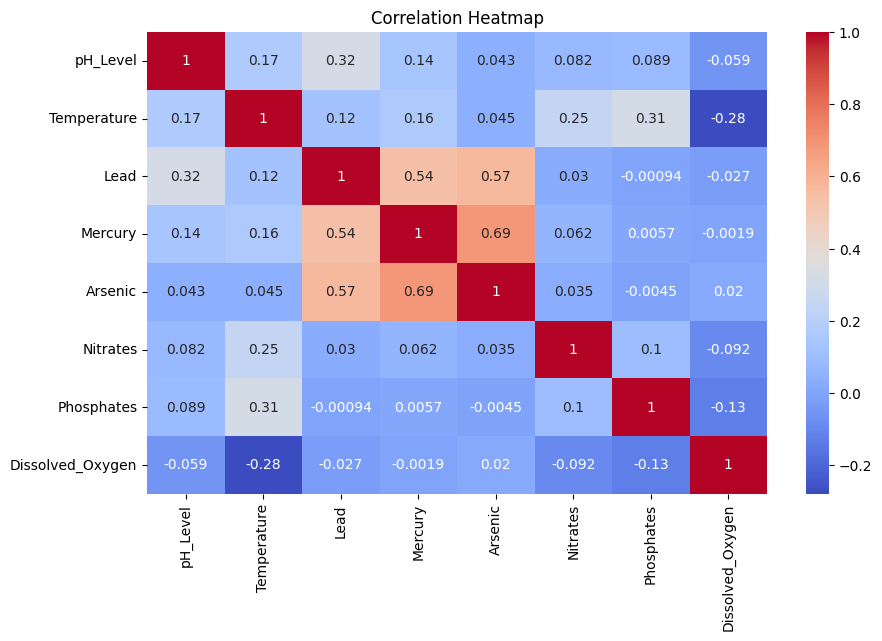

In [70]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### T-Tests: All River Pairs

In [23]:
from itertools import combinations

rivers = df['River_System'].unique()

for toxin in toxins:
    print(f"── {toxin} ──")
    for r1, r2 in combinations(rivers, 2):
        g1 = df[df['River_System'] == r1][toxin]
        g2 = df[df['River_System'] == r2][toxin]
        t_stat, p_value = stats.ttest_ind(g1, g2)

        sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
        print(f"  {r1} vs {r2}: t-stat={t_stat:.3f}, p-value={p_value:.4f} {sig}")
    print()
    

── Lead ──
  Amazon vs Nile: t-stat=-20.238, p-value=0.0000 ***
  Amazon vs Yangtze: t-stat=-44.165, p-value=0.0000 ***
  Amazon vs Mississippi: t-stat=-31.693, p-value=0.0000 ***
  Amazon vs Danube: t-stat=-11.141, p-value=0.0000 ***
  Nile vs Yangtze: t-stat=-22.246, p-value=0.0000 ***
  Nile vs Mississippi: t-stat=-10.448, p-value=0.0000 ***
  Nile vs Danube: t-stat=9.438, p-value=0.0000 ***
  Yangtze vs Mississippi: t-stat=12.087, p-value=0.0000 ***
  Yangtze vs Danube: t-stat=32.876, p-value=0.0000 ***
  Mississippi vs Danube: t-stat=20.541, p-value=0.0000 ***

── Mercury ──
  Amazon vs Nile: t-stat=-23.138, p-value=0.0000 ***
  Amazon vs Yangtze: t-stat=-32.592, p-value=0.0000 ***
  Amazon vs Mississippi: t-stat=-11.629, p-value=0.0000 ***
  Amazon vs Danube: t-stat=10.453, p-value=0.0000 ***
  Nile vs Yangtze: t-stat=-8.818, p-value=0.0000 ***
  Nile vs Mississippi: t-stat=12.103, p-value=0.0000 ***
  Nile vs Danube: t-stat=33.912, p-value=0.0000 ***
  Yangtze vs Mississippi: t-

### Linear regression analysis for toxin levels and pH

In [79]:
X = df[['pH_Level']]
y = df['Lead']
model = LinearRegression()
model.fit(X, y)
print(f"Linear Regression Coefficients: {model.coef_}")
print(f"Linear Regression Intercept: {model.intercept_}")

Linear Regression Coefficients: [0.80294889]
Linear Regression Intercept: -2.893246694927761
